In [43]:
%matplotlib inline
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import pyarrow.parquet as pq
warnings.filterwarnings('ignore')

ROOT_DIR  = '/workspace/ST-GNN Modeling'
GRID_BASE = '/home/data/youngwoong/ST-GNN_Dataset/Data_Preprocessed/Land Use Regression/격자 기본'
TS_LOOKUP = os.path.join(ROOT_DIR, 'RoadExtension_V2/checkpoints/v5_ts_lookup.csv')

CMAP = LinearSegmentedColormap.from_list(
    'pm10', ['#EEF1F5', '#AFCBFF', '#245BFF'])

grid_df   = pd.read_csv(os.path.join(GRID_BASE, '격자_250m_4326.csv'))
LATS, LONS = grid_df['lat'].values, grid_df['lon'].values

v5_data = {
    'train': np.load(os.path.join(ROOT_DIR, 'HiddenExtension_V5/checkpoints/V5-base/grid_pm10_train.npy')),
    'val':   np.load(os.path.join(ROOT_DIR, 'HiddenExtension_V5/checkpoints/V5-base/grid_pm10_val.npy')),
    'test':  np.load(os.path.join(ROOT_DIR, 'HiddenExtension_V5/checkpoints/V5-base/grid_pm10_test.npy')),
}
ts_lookup = pd.read_csv(TS_LOOKUP)
ts_lookup['dt'] = pd.to_datetime(ts_lookup['timestamp'])

print('로드 완료  |  전체 {:,} 타임스텝'.format(len(ts_lookup)))

로드 완료  |  전체 18,251 타임스텝


In [ ]:
# 날짜/시간 설정   (단일 스냅샷용)
TARGET_DT = '2024-03-29 02:00:00'

저장: /workspace/ST-GNN Modeling/Visualization/outputs/snapshot_20240329_0200.png


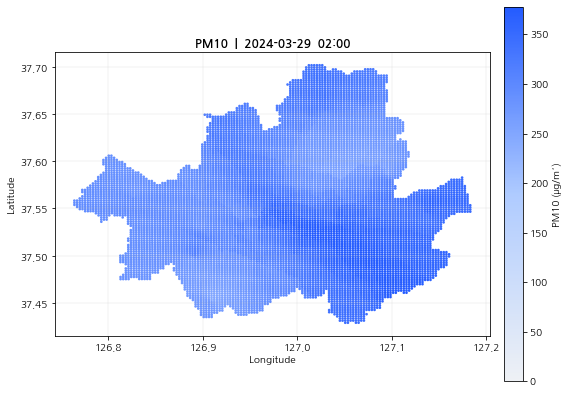

In [50]:
# ── 단일 스냅샷 ──────────────────────────────────────────────────────────
OUT_DIR = os.path.join('/workspace/ST-GNN Modeling/Visualization', 'outputs')
os.makedirs(OUT_DIR, exist_ok=True)

dt    = pd.Timestamp(TARGET_DT)
match = ts_lookup[ts_lookup['dt'] == dt]
if len(match) == 0:
    match = ts_lookup.loc[[(ts_lookup['dt'] - dt).abs().idxmin()]]
row     = match.iloc[0]
ambient = v5_data[row['split']][int(row['local_idx'])]
dt_str  = pd.Timestamp(row['dt']).strftime('%Y-%m-%d  %H:00')

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(LONS, LATS, c=ambient,
                cmap=CMAP, vmin=0, vmax=float(np.percentile(ambient, 99)),
                s=7, linewidths=0)
cbar = plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.03)
cbar.set_label('PM10 (μg/m³)', fontsize=10)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude',  fontsize=10)
ax.set_aspect('equal', adjustable='box')
ax.set_title('PM10  |  {}'.format(dt_str), fontsize=12, fontweight='bold')
ax.grid(True, linewidth=0.4, alpha=0.4)
plt.tight_layout()

fname = 'snapshot_{}.png'.format(pd.Timestamp(row['dt']).strftime('%Y%m%d_%H00'))
out   = os.path.join(OUT_DIR, fname)
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='white')
print('저장:', out)
plt.show()

In [46]:
# ── 편차(std) 상위 10 시간대 계산 ─────────────────────────────────────────
print('전체 {:,} 타임스텝 편차 계산 중...'.format(len(ts_lookup)))

stds = np.empty(len(ts_lookup))
for i, row in ts_lookup.iterrows():
    arr = v5_data[row['split']][int(row['local_idx'])]
    stds[i] = arr.std()

ts_lookup['spatial_std'] = stds
top10 = ts_lookup.nlargest(10, 'spatial_std').reset_index(drop=True)

print('\n편차 상위 10 시간대:')
for _, r in top10.iterrows():
    print('  {}  std={:.2f}'.format(
        pd.Timestamp(r['dt']).strftime('%Y-%m-%d %H:00'), r['spatial_std']))

전체 18,251 타임스텝 편차 계산 중...

편차 상위 10 시간대:
  2024-03-29 11:00  std=38.79
  2024-03-29 10:00  std=37.83
  2024-03-29 03:00  std=34.08
  2024-03-29 12:00  std=33.80
  2024-03-29 02:00  std=31.74
  2024-03-29 13:00  std=29.32
  2023-10-26 22:00  std=28.48
  2025-03-25 16:00  std=27.77
  2024-03-29 04:00  std=27.11
  2024-03-29 09:00  std=26.14


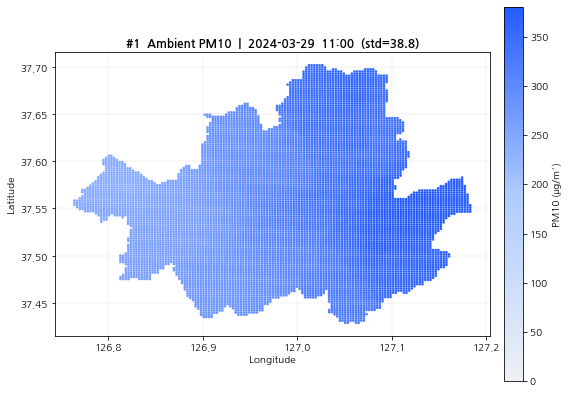

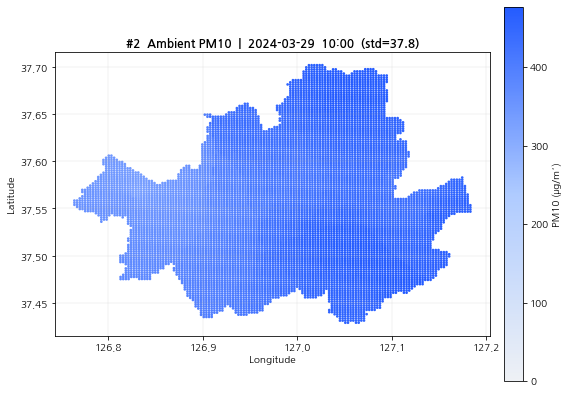

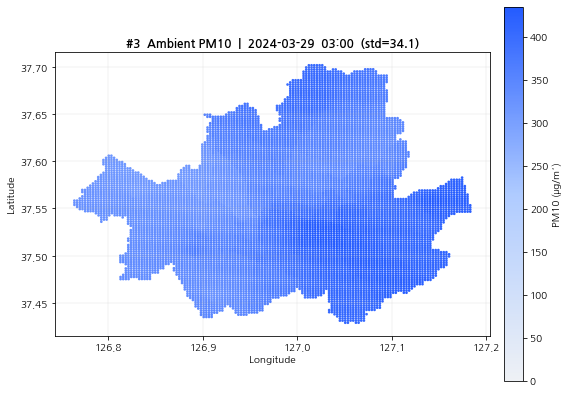

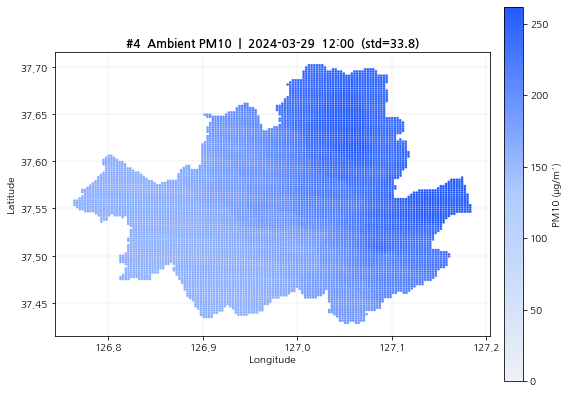

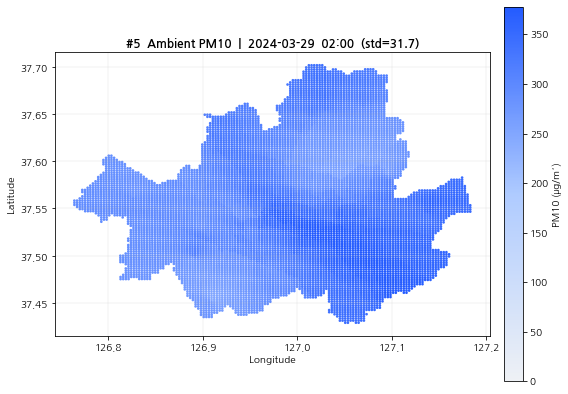

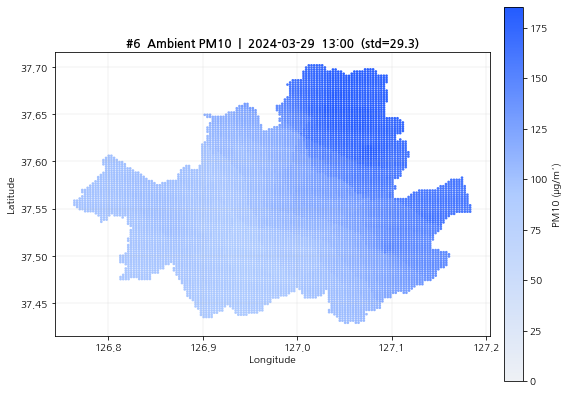

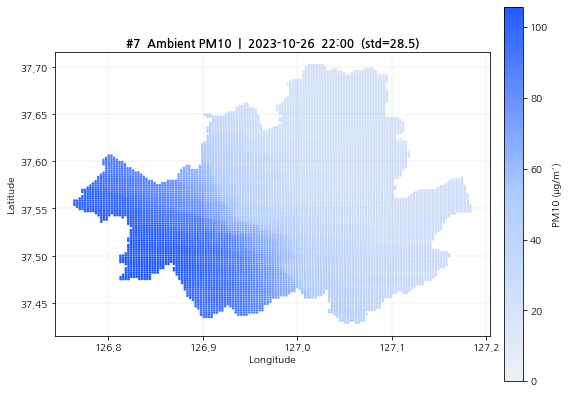

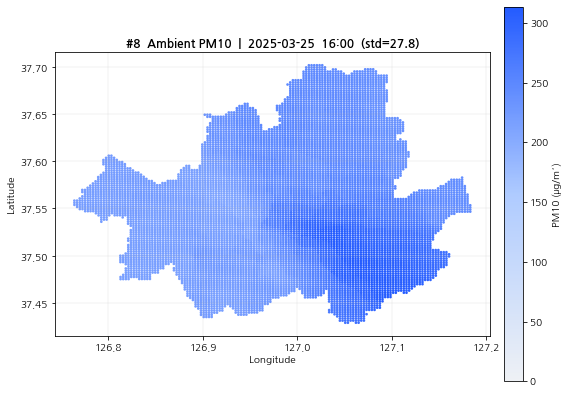

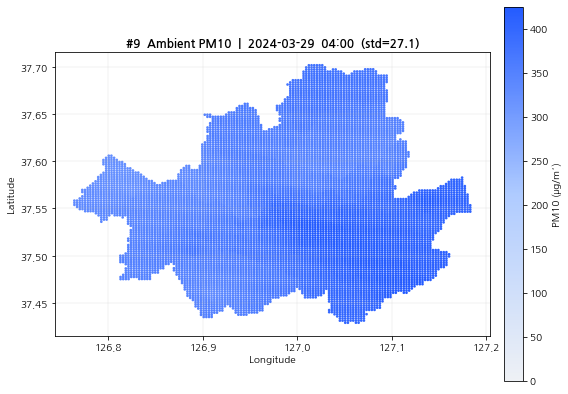

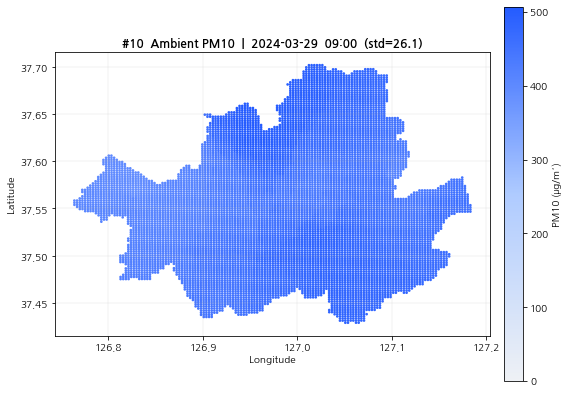

In [47]:
# ── 상위 10 시간대 개별 시각화 ────────────────────────────────────────────
for rank, (_, row) in enumerate(top10.iterrows(), start=1):
    ambient_t = v5_data[row['split']][int(row['local_idx'])]
    dt_label  = pd.Timestamp(row['dt']).strftime('%Y-%m-%d  %H:00')

    fig, ax = plt.subplots(figsize=(8, 7))

    sc = ax.scatter(LONS, LATS, c=ambient_t,
                    cmap=CMAP,
                    vmin=0, vmax=float(np.percentile(ambient_t, 99)),
                    s=7, linewidths=0)

    cbar = plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.03)
    cbar.set_label('PM10 (μg/m³)', fontsize=10)

    ax.set_xlabel('Longitude', fontsize=10)
    ax.set_ylabel('Latitude',  fontsize=10)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title('#{rank}  Ambient PM10  |  {dt}  (std={std:.1f})'.format(
        rank=rank, dt=dt_label, std=row['spatial_std']),
        fontsize=12, fontweight='bold')
    ax.grid(True, linewidth=0.4, alpha=0.4)

    plt.tight_layout()
    plt.show()